<h1>Problem chińskiego listonosza</h1>

Problem chińskiego listonosza został po raz pierwszy opisany w 1962 roku przez chińskiego matematyka o nazwisku Kuan Mei-Ko (znanego też jako Mei-Gu Guan), którego zainspirowała codzienna praca doręczycieli poczty. Zadanie polegało na tym, aby rano odebrać przesyłki z placówki, dostarczyć je do mieszkańców każdej z ulic w mieście, a na koniec dnia bezpiecznie wrócić na pocztę. Chcąc zminimalizować wysiłek, listonosz szukał optymalnej trasy, która pozwoliłaby mu przejść przez każdą ulicę dokładnie raz, bez konieczności powtarzania tego samego odcinka.
Tę sytuację można w bardzo naturalny sposób przełożyć na język teorii grafów. Będziemy zatem rozważać graf ważony, ponieważ zakładamy, że pokonanie poszczególnych ulic wiąże się z różnymi „kosztami” – wyrażonymi na przykład w czasie lub zużyciu paliwa. Ponadto graf ten będzie nieskierowany, jako że większość ulic w naturalny sposób jest dwukierunkowa. 

<h3>Funkcje z zajęć</h3>

In [9]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import random, seed
from copy import deepcopy

def print_matrix(vertices, matrix):
  """
  Wypisuje na ekranie graf podany jako macierz sąsiedztwa
  """
  n = len(matrix)
  if (vertices is None) or (len(vertices) != n):
    vv = range(1, n+1)
  else:
    vv = vertices
  for i in range(n):
    print(vv[i], ':', end='')
    for j in range(n):
      if (matrix[i][j]):
        print(" ", vv[j], end="")
    print("")
def print_dict(graph):
  """
  Wypisuje na ekranie graf podany jako słownik (list) sąsiedztwa
  """
  for v in graph:
    print(v, ':', end="")
    for u in graph[v]:
      print(" ", u, end="")
    print("")
class Graph:
    def __init__(self, graph=None):
        if graph is None:
            graph = {}
        self.graph = graph

    # inicjalizator ze słownika
    @classmethod
    def from_dict(cls, graph):
        return cls(graph)

    # inicjalizator z macierzy
    @classmethod
    def from_matrix(cls, matrix, vertices = None):
        if (vertices is None) or (len(vertices) != len(matrix)):
            vertices = [*range(1, len(matrix) + 1)]
        return cls.from_dict(cls._matrix_to_dict(matrix, vertices))

    # dwie prywatne metody macierz <-> słownik
    def _matrix_to_dict(matrix, vertices: list) -> dict:
        """
        Zamienia graf podany jako macierz sąsiedztwa na słownik sąsiedztwa.
        """
        res_dict = {}
        for i, v in enumerate(vertices):
            neighbours = [vertices[j] for j, edge in enumerate(matrix[i]) if edge]
            res_dict[v] = neighbours
        return res_dict

    def _dict_to_matrix(self, _dict: dict) -> np.array:
        """
        Zamienia graf podany jako słownik sąsiedztwa na macierz sąsiedztwa.
        """
        n = len(_dict)
        vertices = [*_dict.keys()]
        matrix = np.zeros(shape = (n, n), dtype=int)
        for u,v in [
            (vertices.index(u), vertices.index(v))
            for u, row in _dict.items() for v in row
        ]:
            matrix[u][v] += 1
        return matrix

    def vertices(self) -> list:
        """
        Zwraca listę wierzchołków grafu.
        """
        return [*self.graph.keys()]

    def matrix(self) -> np.array:
        """
        Zwraca macierz sąsiedztwa grafu.
        """
        return self._dict_to_matrix(self.graph)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}"
            res += "\n"
        return res

    # Poniższe dostajemy za darmo z powyższego
    def to_neighbourlist(self, filename: str):
        """
        Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy sąsiedztwa).
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        file = open(filename, "w")  # otwarcie pliku tekstowego do zapisu
        file.write(str(self))
        file.close()

    # rysowanie grafów
    def plot(self, directed=0):
        """
        Rysuje graf używając metod biblioteki networkx.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
          G = nx.Graph(self.graph)
        pos = nx.spring_layout(G)
        nx.draw(G, pos, with_labels=True)
        plt.show()


    # Modyfikacje grafów
    def add_vertex(self, vertex):
        """
        Dodaje wierzchołek do grafu
        """
        if vertex not in self.graph:
            self.graph[vertex] = []

    def del_vertex(self, vertex):
        """
        Usuwa wierzchołek z grafu
        """
        if vertex in self.graph:
            self.graph.pop(vertex)
            for u in self.graph:
                if vertex in self.graph[u]:
                    self.graph[u].remove(vertex)

    def add_arc(self, arc):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        u, v = arc
        self.add_vertex(u)
        self.add_vertex(v)
        if v not in self.graph[u]:
            self.graph[u].append(v)

    def add_edge(self, edge: list):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        if u == v:
            raise ValueError("Pętle nie są dopuszczalne!")
        self.add_vertex(u)
        self.add_vertex(v)
        
        self.graph[u].append(v)
        self.graph[v].append(u)

    # czytanie z plików
    @staticmethod
    def from_edges(filename: str, directed = 0):
        """
        Tworzy graf na podstawie pliku z łukami/krawędziami.
        Opis łuku/krawędzi to dwa słowa lub wierzchołka (jedno słowo).
        Nadmiarowe słowa są ignorowane.
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        graph = Graph()
        file = open(filename, "r")          # otwarcie pliku do odczytu
        for line in file:                   # dla każdej linii w pliku
          words = line.strip().split()      # rozdziel linię na słowa
          if len(words) == 1:               # jedno słowo - opis wierzchołka
            graph.add_vertex(words[0])
          elif len(words) >= 2:             # conajmnej 2 słowa - opis krawędzi/łuku
            if directed:
              graph.add_arc([words[0], words[1]])
            else:
              graph.add_edge([words[0], words[1]])
        file.close()
        return graph

    def to_edges(self, filename, directed=1):
      """
      Zapisuje graf podany jako słownik (list) sąsiedztwa do pliku (w formie listy krawędzi).
      Zapis jako grafd skierowany lub nieskierowany zależy od wartości zmiennej directed.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      with open(filename,"w") as file:
        wierzcholki = list(self.graph.keys())
        for v in self.graph:
          if len(self.graph[v]) > 0:
            for u in self.graph[v]:
              if ((directed) or (wierzcholki.index(v) < wierzcholki.index(u))):
                line = f"{v} {u}\n"
                file.write(line)
          else:
                file.write(v + "\n")

    @staticmethod
    def from_neighbourlist(filename, directed=0):
      """
      Tworzy graf na podstawie pliku z listą sąsiedztwa.
      Zmienna filename zawiera pełną ścieżkę pliku
      """
      graph = Graph()
      with open(filename, 'r') as file:
        for line in file:
          line = line.replace(":", "")
          words = list(line.strip().split())
          graph.add_vertex(words[0])
          for i in range(1,len(words)):
            if directed:
              graph.add_arc((words[0],words[i]))
            else:
              graph.add_edge((words[0],words[i]))
      return graph

    @staticmethod
    def random_graph(n: int, p: float):
        """
        Tworzy losowy graf nieskierowany G(n,p)
        """
        rand_graph = Graph()
        for i in range(1, n + 1):
            rand_graph.add_vertex(i)
            for j in range(1, i):
                if random() < p:
                    rand_graph.add_edge([i, j])
        return rand_graph

    @staticmethod
    def cycle(n: int):
        """
        Tworzy graf cykliczny o n wierzchołkach
        """
        cycle = Graph()
        for i in range(n-1):
          cycle.add_edge([i+1, i+2])
        cycle.add_edge([1, n])
        return cycle

    def Prufer(self):
        """
        Zwraca kod Prüfera drzewa.
        Nie jest sprawdzane, czy graf jest drzewem. Dla nie drzew może działać źle.
        Wynik podany jako napis (pusty gdy jest mniej niż 3 wierzchołki).
        """
        tr = deepcopy(self.graph)   # kopia słownika grafu
        code = ""
        for i in range(len(self.graph)-2):
          for x in sorted(tr):
            if len(tr[x])==1:     # najmniejszy liść
              break
          v = tr[x][0]            # sąsiad najmniejszego liścia
          code += f"{v} "
          tr.pop(x)
          tr[v].remove(x)
        return code.strip()

    @staticmethod
    def tree_from_Prufer(code :str):
      """
      Tworzy drzewo z kodu Prüfera
      """
      tree = Graph()
      clist = [int(x) for x in code.strip().split()]  # kod jako lista liczb
      n = len(clist) + 2    # liczba wierzchołków
      vert = [*range(1, n + 1)]
      for v in vert:
        tree.add_vertex(v)
      for i in range(n-2):
        for x in vert:
          if x not in clist:    # najmniejszy liść
            break
        v = clist.pop(0)  # sąsiad najmniejszego liścia
        tree.add_edge([x, v])
        vert.remove(x)
      tree.add_edge(vert) # na liście vert zostały 2 elementy - ostatnia krawędź
      return tree

    def connected_components(self):
        """
        Zwraca listę składowych spójnych (nieskierowanego) grafu.
        Zwraca listę zbiorów wierzchołków.
        Uwaga: zerowy element listy zawiera wszystkie wierzchołki.
        """
        def DFS(u):
          """
          Przechodzenie wgłąb - funkcja wewnętrzna
          """
          for w in self.graph[u]:
            if w not in VT[0]:    # w - jeszcze nieodwiedzony
              VT[0].add(w)
              VT[-1].add(w)
              DFS(w)

        """
        VT - lista zbiorów wierzchołków
        VT[0] - docelowo zbiór wszystkich wierzchołków
        """
        VT = [set([])]
        for v in self.graph:
          if v not in VT[0]:  # v - nieodwiedzony
            VT[0].add(v)      # już odwiedzony
            VT.append(set([v])) # zalążen nowej spójnej składowej
            DFS(v)
        return VT

    def connected_components_graphs(self):
        """
        Zwraca listę składowych spójnych (nieskierowanego) grafu.
        Zwraca listę grafów.
        """
        components = self.connected_components()  # lista zbiorów wierzchołków
        components_graphs = []
        for comp in components[1:]:
          subgraph = Graph()
          for v in comp:
            subgraph.graph[v] = self.graph[v].copy()
          components_graphs.append(subgraph)
        return components_graphs

    def distance(self, v):
        """
        Oblicza odległości z v do innych wierzchołków grafu. Zwraca słownik.
        Używa BFS.
        """
        dist = {v: 0}   # zalążek słownika
        queue = [v]     # kolejka wierzchołków
        while len(queue) > 0:
            u = queue.pop(0)
            for w in self.graph[u]:
                if w not in dist:
                    dist[w] = dist[u] + 1
                    queue.append(w)
        return dist

    def preorder(self, v, visited=None):
      """
       Wypisuje drzewo w porządku preorder, zaczynając od wierzchołka v.
        Uwaga: nie jest sprawdzane, czy graf jest drzewem, ale w tej wersji się nie zawiesi.
      """
      if visited is None:
        visited = set()

      visited.add(v)
      print(v, end=" ")

      for u in self.graph[v]:
        if u not in visited:
          self.preorder(u, visited)


    def postorder(self, v, visited=None):
       """
        Wypisuje drzewo w porządku preorder, zaczynając od wierzchołka v.
        Uwaga: nie jest sprawdzane, czy graf jest drzewem, ale w tej wersji się nie zawiesi.
       """
       if visited is None:
          visited = set()

       visited.add(v)

       for u in self.graph[v]:
          if u not in visited:
            self.postorder(u, visited)

       print(v, end=" ")

    @staticmethod
    def random_bipartite_graph(n: int, p: float):
        """
        Tworzy losowy graf dwudzielny o 2n wierzchołkach.
        Pierwsza część to wierzchołki 1, 2, ..., n,
        druga część to wierzchołki n+1, n+2, ..., 2n.
        Każda możliwa krawędź między częściami jest losowana
        niezależnie z prawdopodobieństwem p.
        """
        #pusty graf
        g = Graph()

        # podział na dwie części
        A = list(range(1, n + 1))
        B = list(range(n + 1, 2*n + 1))

        # wierzchołki
        for v in A + B:
          g.add_vertex(v)

        # losowe krawędzie
        for u in A:
          for v in B:
            if random() < p:
                g.add_edge([u, v])

        return g

In [10]:
from queue import PriorityQueue

class WeightedGraph(Graph):
    def __init__(self, graph=None, weights=None):
        if weights is None:
            weights = {}
        self.weights = weights
        super().__init__(graph)

    # inicjalizator ze słownika
    @classmethod
    def from_dict(cls, graph, weights):
        return cls(graph, weights)

    # przedefiniowania sposobu wyświetlania grafów
    def __str__(self):
        res = ""
        for v in self.graph:
            res += f"{v}:"
            for u in self.graph[v]:
                res += f" {u}({self.weights[(v, u)]})"
            res += "\n"
        return res

   # rysowanie grafów
    def plot(self, directed=0):
        """
        Rysuje graf ważony używając metod biblioteki networkx.
        """
        if directed:
            G = nx.DiGraph(self.graph)
        else:
          G = nx.Graph(self.graph)
        for u,v in self.weights:
          G.edges[u,v]['weight'] = self.weights[(u,v)]
        pos = nx.spring_layout(G)
        labels = nx.get_edge_attributes(G,'weight')
        nx.draw(G, pos, with_labels=True)
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
        plt.show()

    def add_arc(self, arc, weight = 1):
        """
        Dodaje łuk (skierowany, podany jako para wierzchołków) do grafu
        """
        super().add_arc(arc)
        self.weights[arc] = weight

    def add_edge(self, edge: list, weight = 1):
        """
        Dodaje krawędź (podaną jako para wierzchołków) do grafu
        Rozpatrujemy grafy proste, nieskierowane
        """
        u, v = edge
        super().add_edge(edge)
        self.weights[(u, v)] = weight
        self.weights[(v, u)] = weight

    # czytanie z plików
    @staticmethod
    def from_edges(filename: str, directed = 0):
        """
        Tworzy graf na podstawie pliku z łukami/krawędziami.
        Opis łuku/krawędzi to dwa słowa lub wierzchołka (jedno słowo),
        albo 3 słowa: wierzchołek, wierzchołek, waga.
        Nadmiarowe słowa są ignorowane.
        Zmienna filename zawiera pełną ścieżkę pliku
        """
        wgraph = WeightedGraph()
        file = open(filename, "r")          # otwarcie pliku do odczytu
        for line in file:                   # dla każdej linii w pliku
          words = line.strip().split()      # rozdziel linię na słowa
          if len(words) == 1:               # jedno słowo - opis wierzchołka
            wgraph.add_vertex(words[0])
          elif len(words) == 2:             # 2 słowa - opis krawędzi/łuku bez wag
            if directed:
              wgraph.add_arc([words[0], words[1]])
            else:
              wgraph.add_edge([words[0], words[1]])
          elif len(words) >= 3:             # co najmniej 3 słowa - opis krawędzi/łuku z wagami
            if directed:
              wgraph.add_arc([words[0], words[1]], int(words[2]))
            else:
              wgraph.add_edge([words[0], words[1]], int(words[2]))
        file.close()
        return wgraph


    def min_spanning_tree(self):
        """
        Zwraca drzewo rozpinające wg algorytmu Jarnika-Prima.
        """
        for v in self.graph:
          break
        wtree = WeightedGraph({v: []})
        total = 0     # łączna waga drzewa
        pq = PriorityQueue()
        for u in self.graph[v]:
          pq.put((self.weights[(v, u)], v, u))
        while not pq.empty():
          w, v, u = pq.get()
          if not u in wtree.graph:
            wtree.add_edge((u, v), w)
            total += w
            for x in self.graph[u]:
              if not x in wtree.graph:
                pq.put((self.weights[(u, x)], u, x))
        if len(wtree.graph) < len(self.graph):
          print("Graf niespojny! Zwrócono drzewo dla jednej spójnej składowej.")
        return wtree, total

    def _dict_to_matrix(self, _dict: dict) -> np.array:
        """
        Zamienia graf ważony podany jako słownik sąsiedztwa na macierz sąsiedztwa z uwzględnieniem wag.
        """
        # Wywołujemy oryginalną metodę z klasy bazowej (Graph), która stworzy macierz z jedynkami
        matrix = super()._dict_to_matrix(_dict)
        
        vertices = [*_dict.keys()]
        
        for (u, v), weight in self.weights.items():
            if u in _dict and v in _dict[u]:
                u_idx = vertices.index(u)
                v_idx = vertices.index(v)
                matrix[u_idx][v_idx] = weight     
        return matrix

    def matrix(self) -> np.array:
        """
        Zwraca macierz sąsiedztwa ważonego grafu.
        """
        return self._dict_to_matrix(self.graph)

    @classmethod
    def _matrix_to_dict(cls, matrix, vertices: list) -> tuple:
        """
        Zamienia macierz sąsiedztwa z wagami na strukturę grafu ważonego.
        Zwraca krotkę: (słownik_sąsiedztwa, słownik_wag)
        """
        res_dict = {}
        res_weights = {}
        
        for i, u in enumerate(vertices):
            neighbours = []
            for j, v in enumerate(vertices):
                weight = matrix[i][j]
                if weight != 0:  # Jeśli waga jest różna od 0, istnieje krawędź
                    neighbours.append(v)
                    res_weights[(u, v)] = weight
            res_dict[u] = neighbours
            
        return res_dict, res_weights
    @classmethod
    def from_matrix(cls, matrix, vertices = None):
        """
        Tworzy obiekt klasy WeightedGraph na podstawie macierzy z wagami.
        """
        # Sprawdzamy wierzchołki dokładnie tak samo jak w klasie bazowej
        if (vertices is None) or (len(vertices) != len(matrix)):
            vertices = [*range(1, len(matrix) + 1)]
            
        # Wywołujemy naszą nową, dedykowaną dla grafu ważonego metodę
        graph_dict, weights_dict = cls._matrix_to_dict(matrix, vertices)  
        return cls.from_dict(graph_dict, weights_dict)

    def floyd_warshall(self) -> np.array:
        """
        Oblicza macierz najkrótszych odległości między wszystkimi wierzchołkami
        używając algorytmu Floyda-Warshalla.
        """
        base_matrix = self._dict_to_matrix(self.graph)
        n = len(base_matrix)
        
        # Zastępujemy 0 wartością nieskończoności (float('inf')), ponieważ 0 oznacza brak połączenia
        dist_matrix = np.where(base_matrix == 0, float('inf'), base_matrix)
        
        # Odległość wierzchołka do samego siebie to zawsze 0 (zerujemy przekątną)
        for i in range(n):
            dist_matrix[i][i] = 0.0
                 
        # 3. Główny algorytm Floyda-Warshalla (potrójna pętla)
        for k in range(n):       # wierzchołek pośredniczący
            for i in range(n):   # wierzchołek startowy
                for j in range(n): # wierzchołek końcowy
                    # Relacja relaksacji: sprawdzamy, czy droga przez 'k' jest krótsza
                    if dist_matrix[i][k] + dist_matrix[k][j] < dist_matrix[i][j]:
                        dist_matrix[i][j] = dist_matrix[i][k] + dist_matrix[k][j]
                        
        return dist_matrix
        
        #---------------------------- nowa część ----------------------------
    def get_vertex_degrees(self) -> dict:
        """
        Zwraca słownik, gdzie kluczem jest wierzchołek, 
        a wartością liczba jego krawędzi.
        """
        degrees = {}
        for vertex in self.graph:
            degrees[vertex] = len(self.graph[vertex])
        return degrees
    def get_odd_vertices(self) -> list:
        """
        Zwraca listę wierzchołków, które mają nieparzysty stopień.
        """
        degrees = self.get_vertex_degrees()
        return [vertex for vertex, deg in degrees.items() if deg % 2 != 0]
    def check_eulerian_conditions(self) -> tuple:
        """
        Sprawdza warunki konieczne dla grafu eulerowskiego:
        1. Czy graf jest spójny pomijając wierzchołki izolowane, możemy tak zrobić ponieważ wierzchołek izolowany nie ma żadnej krawędzi.
        2. Czy lista wierzchołków o nieparzystym stopniu jest pusta.
        
        Zwraca krotkę: (czy_spojny, czy_brak_nieparzystych)
        """
        components = super().connected_components()

        #Wycinamy wierzchołki odizolowane
        real_components = components[1:]
        
        active_components = []
        for comp in real_components:
            #Jeśli składowa ma tylko 1 element, sprawdzamy czy jest izolowany (stopień == 0)
            if len(comp) == 1:
                v = list(comp)[0]
                if len(self.graph[v]) > 0: #Może być teoretycznie połączony sam ze sobą
                    active_components.append(comp)
            else:
                active_components.append(comp)
        
        is_connected = len(active_components) <= 1
        
        odd_vertices = self.get_odd_vertices()
        no_odd_vertices = len(odd_vertices) == 0
        
        return is_connected, no_odd_vertices

    def dijkstra(self, start_vertex) -> tuple:
        """
        Oblicza najkrótsze ścieżki z wierzchołka start_vertex do wszystkich innych
        używając algorytmu Dijkstry.
        
        Zwraca krotkę: (słownik_odległości, słownik_poprzedników)
        """
        from queue import PriorityQueue
        
        distances = {v: float('inf') for v in self.graph}
        predecessors = {v: None for v in self.graph}
        
        distances[start_vertex] = 0 #Odległość od samego siebie 
        
        #Kolejka priorytetowa przechowująca pary (odległość, wierzchołek)
        pq = PriorityQueue()
        pq.put((0, start_vertex))
        
        while not pq.empty(): #Działa dopłuki są wpisy do sprawdzenia
            current_dist, u = pq.get() #Usuwa z kolejki
            
            if current_dist > distances[u]:
                continue #Jeśli jest już lepsza trasa to zostawiamy ten warunek
                
            for v in self.graph[u]:
                weight = self.weights[(u, v)]
                distance = current_dist + weight
                
                if distance < distances[v]:
                    distances[v] = distance
                    predecessors[v] = u
                    pq.put((distance, v))          
        return distances, predecessors

    def find_eulerian_circuit(self, start_vertex) -> list: #algorytm Hierholzera
        """
        Krótki opis algorytmu:
         * algorytm zaczyna w punkcie A i robi pętlę wędrując po krawędziach aż wróci do punktu A
         * zapisuje sobie trasę jaką przeszedł czyli np A -> B -> C -> A, na bieżąco usuwając z listy krawędzie po krórych przeszedł
         * szuka on teraz jakiegoś wierzchołka który masz jeszcze dostępne (nieprzebyte) krawędzie (zaczynając od ostatniego punktu) i tak jak poprzednio idzie na spacer
         * jak znajdzie taka pętle wkleja on je w miejsce gdzie punkt startowy jest w głównej trasie np.
             jeśli mieliśmy trasę A -> B -> C -> A, a kolejna trasa to B -> E -> F -> B to po sklejeniu będzie to wyglądać tak
             A -> |B -> E -> F -> B| -> C -> A
         * algorytm kończymy jak nie będzie już żadnego wierzchołka z dostępnymi krawędziami
        """

    
        adj_remaining = {u: list(self.graph[u]) for u in self.graph}
        
        stack = [start_vertex]
        circuit = []
        
        while stack: #Działa dopłóki są elementy w stosie
            current_v = stack[-1] #Aktualna pozycja
            if adj_remaining[current_v]: #Sprawdza czy wierzchołek ma jakieś nieodwiedzone krawędzie  
                next_v = adj_remaining[current_v].pop() #Wyciąga i usuwa ostatni edge z listy dostępnych
                
                if current_v in adj_remaining[next_v]: #Usunięcie tej samej krawędzi w drugą stronę
                    adj_remaining[next_v].remove(current_v)
            
                stack.append(next_v)
            else: #tutaj przechodzi dopiero jak pętla wróci już do A oraz wykorzysta już wszystkie możliwe krawędzie dla niej (czyli może to być parę pętli)
                #Implementacja pythonowa działa tutaj troszkę inaczej niż w opisie. Otóż jeśli mamy przykładową pętlę A -> B -> C -> A,
                #dodajemy i usuwamy ostani odwiedzony wierzchołek czyli A, po czym zostaniemy z trasa A -> B -> C  w stacku
                #Teraz algorytm sprawdzi czy wierchołek C ma jakies nieodwiedzone krawędzie, jak tak to tam pójdzie, a jak nie to doda C do wyniku
                circuit.append(stack.pop()) 
                
        return circuit[::-1] #Poniważ kroki trasy dodawane są od końca teraz musimy trase odwrócić

    def get_odd_vertices_paths(self) -> dict:
        """
        Dla każdego wierzchołka o nieparzystym stopniu uruchamia algorytm Dijkstry.
        
        Zwraca słownik o strukturze:
        {
            v: {
                'distances': {u: odległość, ...},
                'predecessors': {u: poprzednik, ...}
            },
            ...
        }
        gdzie 'v' to wierzchołek o nieparzystym stopniu.
        """
        odd_vertices = self.get_odd_vertices()
        odd_paths_data = {}
        for v in odd_vertices:
            distances, predecessors = self.dijkstra(v)
            odd_paths_data[v] = {
                'distances': distances,
                'predecessors': predecessors
            }        
        return odd_paths_data

    def find_best_matching(self, odd_vertices: list, odd_paths_data: dict) -> list:
        """
        Znajduje optymalne parowanie wierzchołków nieparzystych o minimalnym sumarycznym koszcie.
        Wykorzystuje podejście rekurencyjne.

        Opis algorytmu:
         * Z Dikrstry liczy odeległości od wszystkich nieparzystyc wierzchołków od siebie (funkcja get_odd_vertices_paths)
         * Algorytm wybiera pierwszy wierzchołek z brzegu (np. A)
         * Zapisuje jakie sumy wszystkich odleglosci będą dla różnych par A, czyli dla  AB, AC, AD i wybiera tą najmniejszą 
         * Jak jest więcej przypadków rekurencyjnie liczy odległości między wszystkimi innymi wierzchołkami
         * Potem robi to samo w oparciu o zbiór wierzchołków bez tych dwóch wsześniej wybranych
        """
        if not odd_vertices:
            return [], 0
            
        u = odd_vertices[0]
        best_cost = float('inf')
        best_matching = []
        
        for i in range(1, len(odd_vertices)): #1 aby nie łaczyć go z samym sobą
            v = odd_vertices[i]
            
            cost_uv = odd_paths_data[u]['distances'][v]
            
            remaining_vertices = [x for x in odd_vertices if x != u and x != v]
            
            sub_matching, sub_cost = self.find_best_matching(remaining_vertices, odd_paths_data)
            
            total_cost = cost_uv + sub_cost
            
            if total_cost < best_cost:
                best_cost = total_cost
                best_matching = [(u, v)] + sub_matching
                
        return best_matching, best_cost

    def add_virtual_edges(self, best_matching: list, odd_paths_data: dict):
        """
        Dla każdej pary z optymalnego parowania odtwarza najkrótszą ścieżkę
        i dodaje krawędzie w grafie wzdłuż tej ścieżki.
        """
        for u, v in best_matching:
            predecessors = odd_paths_data[u]['predecessors']
            
            path = []
            current = v
            while current is not None:
                path.append(current)
                current = predecessors[current]
            
            path = path[::-1]
            
            for i in range(len(path) - 1):
                node1 = path[i]
                node2 = path[i+1]
                
                weight = self.weights[(node1, node2)]
                
                self.add_edge([node1, node2], weight)

    def chinski_listonosz(self, start_vertex):
        """
        Główna metoda rozwiązująca Problem Chińskiego Listonosza.
        Modyfikuje graf dodając wirtualne krawędzie (jeśli to konieczne) 
        i zwraca ostateczną, optymalną trasę listonosza.
        """
        is_connected, no_odd_vertices = self.check_eulerian_conditions()

        if not is_connected:
            raise ValueError("Graf nie jest spójny! Listonosz nie może odwiedzić wszystkich ulic.")

        base_cost = sum(self.weights.values()) // 2 #Dzielimy przez 2 aby nie liczyć podwójnie

        if no_odd_vertices:
            print("Graf jest już eulerowski (brak wierzchołków nieparzystych).")
            print("Znajdywanie trasy")
            return self.find_eulerian_circuit(start_vertex), base_cost
            
        print("Graf nie jest eulerowski. Rozpoczynam procedurę parowania...")
        
        odd_vertices = self.get_odd_vertices()
        
        odd_paths_data = self.get_odd_vertices_paths()
        
        best_matching, additional_cost = self.find_best_matching(odd_vertices, odd_paths_data)
        print(f"Optymalne pary wierzchołków do połączenia: {best_matching}")
        print(f"Suma wag dodatkowo pokonanych ulic: {additional_cost}")

        total_cost = base_cost + additional_cost
        
        self.add_virtual_edges(best_matching, odd_paths_data)
        print("Dodano wirtualne krawędzie. Graf stał się eulerowski!")
        print("Znajdywanie trasy")
        
        
        final_route = self.find_eulerian_circuit(start_vertex)
        return final_route,total_cost

Jedyna zmiana jaka nastąpiła w istniejącym kodzie to w "add_edge" usunięto warunek, który nie pozwalał na występowanie więcej niż jednego połączenia między dwoma wierzchołkami. Zostało to zmienione, ponieważ ważną częścią naszego algorytmu będzie właśnie dodawanie takich wirtualnych krawędzi.

<h2>Opis algorytmu chińskiego listonosza</h2>

 * Sprawdzenie czy graf jest spójny z dokładnością do izolowanych wirzchołków i czy ma wierzchołki z nieparzystą liczbą połączeń (czy to graf eulerowski)
   * W przypadku, gdy graf nie jest spójny z dokładnością do izolowanych wirzchołków to nie możemy przeprowadzić na nim tego algorytmu, gdyż listonosz nie będzie mógł przejść przez wszystkie krawędzie
   * W idealnej sytuacji graf nie będzie miał nieparzystych wierzchołków, wtedy pozwala nam opuścić sporą część algorytmu
 * Jeśli nam graf ma nieparzyste wierzchołki, będziemy dodawać wirtualne krawędzie, aby nieparzyste krawędzie stały się parzyste. Robimy to następująco:
   * Identyfikujemy wszystkie nieparzyste wierzchołki
   * Algorytm znajduje najkrótszy sposób na połącznie tych wierzchołków korzystając z algorytmu Djikstry
   * Dodajemy teraz dodatkowe "wirtualne" krawędzie zgodnie ze znalezioną wcześniej trasą
   * W wyniku tych kroków graf staje się eulerowski
 * Jak już sprawiliśmy, że nasz graf jest eulerowski wyzanczamy optymalną trasę z algorytmu Hierholzera

<h1>Testowanie algorytmu</h1>

<h3>Przypadek Idealny</h3>

URUCHOMIENIE PEŁNEGO ALGORYTMU LISTONOSZA
Graf jest już eulerowski (brak wierzchołków nieparzystych).
Znajdywanie trasy
Ostateczna, optymalna trasa dla listonosza:
A -> F -> H -> E -> F -> G -> D -> F -> B -> E -> C -> D -> A -> C -> B -> A
Koszt trasy to:59


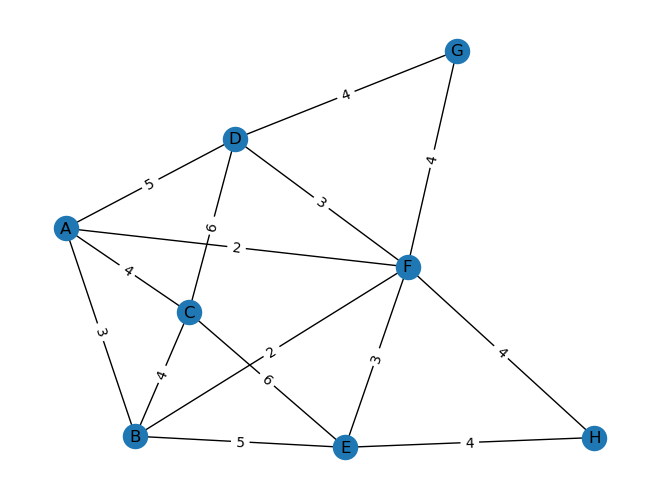

In [11]:
wgraph_1 = WeightedGraph()
wgraph_1.graph = {
    'A': ['B', 'C', 'D', 'F'],      
    'B': ['A', 'C', 'E', 'F'],      
    'C': ['A', 'B', 'D', 'E'],      
    'D': ['A', 'C', 'F', 'G'],      
    'E': ['B', 'C', 'F', 'H'],      
    'F': ['A', 'B', 'D', 'E', 'G', 'H'],
    'G': ['D', 'F'],                 
    'H': ['E', 'F']                  
}
wgraph_1.weights = {
    ('A', 'B'): 3, ('B', 'A'): 3,
    ('A', 'C'): 4, ('C', 'A'): 4,
    ('A', 'D'): 5, ('D', 'A'): 5,
    ('A', 'F'): 2, ('F', 'A'): 2,
    
    ('B', 'C'): 4, ('C', 'B'): 4,
    ('B', 'E'): 5, ('E', 'B'): 5,
    ('B', 'F'): 2, ('F', 'B'): 2,
    
    ('C', 'D'): 6, ('D', 'C'): 6,
    ('C', 'E'): 6, ('E', 'C'): 6,
    
    ('D', 'F'): 3, ('F', 'D'): 3,
    ('D', 'G'): 4, ('G', 'D'): 4,
    
    ('E', 'F'): 3, ('F', 'E'): 3,
    ('E', 'H'): 4, ('H', 'E'): 4,
    
    ('F', 'G'): 4, ('G', 'F'): 4,
    ('F', 'H'): 4, ('H', 'F'): 4
}

print("URUCHOMIENIE ALGORYTMU LISTONOSZA")
listonosz_1 = wgraph_1.chinski_listonosz('A')

print("\nOstateczna, optymalna trasa dla listonosza:")
print(" -> ".join(listonosz_1[0]))

print(f"\nKoszt trasy to:{listonosz_1[1]}")
wgraph_1.plot()

<h3>Przypadek standardowy

URUCHOMIENIE PEŁNEGO ALGORYTMU LISTONOSZA
Graf nie jest eulerowski. Rozpoczynam procedurę parowania...
Optymalne pary wierzchołków do połączenia: [('D', 'E'), ('G', 'H')]
Suma wag dodatkowo pokonanych ulic: 14
Dodano wirtualne krawędzie. Graf stał się eulerowski!
Znajdywanie trasy

Ostateczna, optymalna trasa dla listonosza:
A -> F -> H -> F -> G -> F -> E -> F -> D -> F -> B -> E -> C -> D -> A -> C -> B -> A
Koszt trasy to: 65


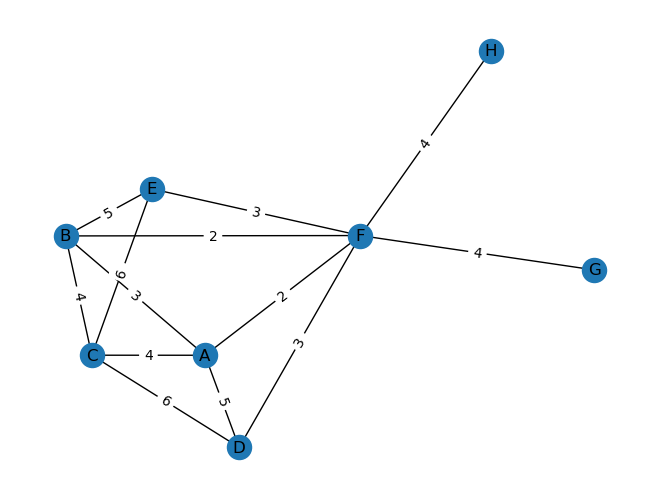

In [12]:
wgraph_2 = WeightedGraph()
wgraph_2.graph = {
    'A': ['B', 'C', 'D', 'F'],      
    'B': ['A', 'C', 'E', 'F'],      
    'C': ['A', 'B', 'D', 'E'],      
    'D': ['A', 'C', 'F'],                
    'E': ['B', 'C', 'F'],          
    'F': ['A', 'B', 'D', 'E', 'G', 'H'],
    'G': ['F'],                                   
    'H': ['F']                                
}
wgraph_2.weights = {
    ('A', 'B'): 3, ('B', 'A'): 3,
    ('A', 'C'): 4, ('C', 'A'): 4,
    ('A', 'D'): 5, ('D', 'A'): 5,
    ('A', 'F'): 2, ('F', 'A'): 2,
    ('B', 'C'): 4, ('C', 'B'): 4,
    ('B', 'E'): 5, ('E', 'B'): 5,
    ('B', 'F'): 2, ('F', 'B'): 2,
    ('C', 'D'): 6, ('D', 'C'): 6,
    ('C', 'E'): 6, ('E', 'C'): 6,
    ('D', 'F'): 3, ('F', 'D'): 3,
    ('E', 'F'): 3, ('F', 'E'): 3,
    ('F', 'G'): 4, ('G', 'F'): 4,
    ('F', 'H'): 4, ('H', 'F'): 4
}

print("URUCHOMIENIE ALGORYTMU LISTONOSZA")
listonosz_2 = wgraph_2.chinski_listonosz('A')

print("\nOstateczna, optymalna trasa dla listonosza:")
print(" -> ".join(listonosz_2[0]))

print(f"\nKoszt trasy to: {listonosz_2[1]}")
wgraph_2.plot()

<h3>Inny przypadek standardowy</h3>

URUCHOMIENIE ALGORYTMU DLA POŁĄCZENIA NIEBEZPOŚREDNIEGO (PRZYPADEK 3)
Graf nie jest eulerowski. Rozpoczynam procedurę parowania...
Optymalne pary wierzchołków do połączenia: [('A', 'X'), ('B', 'Y')]
Suma wag dodatkowo pokonanych ulic: 4
Dodano wirtualne krawędzie. Graf stał się eulerowski!
Znajdywanie trasy

Ostateczna, optymalna trasa dla listonosza:
A -> X -> A -> C -> F -> B -> Y -> B -> A

Koszt trasy to: 35


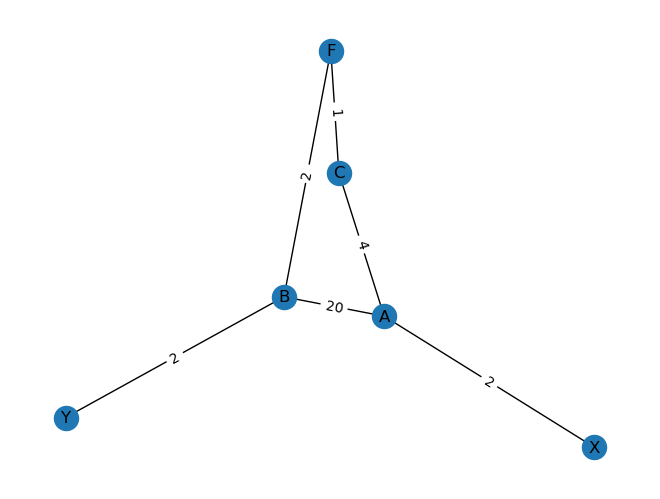

In [13]:
wgraph_3 = WeightedGraph()
wgraph_3.graph = {
    'A': ['B', 'C'],       
    'B': ['A', 'F'],
    'C': ['A', 'F'],      
    'F': ['B', 'C']       
}
wgraph_3.weights = {
    ('A', 'B'): 20, ('B', 'A'): 20,
    ('A', 'C'): 4,  ('C', 'A'): 4,
    ('C', 'F'): 1,  ('F', 'C'): 1,
    ('F', 'B'): 2,  ('B', 'F'): 2
}

wgraph_3.graph = {
    'A': ['B', 'C', 'X'],  
    'B': ['A', 'F', 'Y'],  
    'C': ['A', 'F'],       
    'F': ['B', 'C'],       
    'X': ['A'],            
    'Y': ['B']              
}
wgraph_3.weights = {
    ('A', 'B'): 20, ('B', 'A'): 20, 
    ('A', 'C'): 4,  ('C', 'A'): 4,
    ('C', 'F'): 1,  ('F', 'C'): 1,
    ('F', 'B'): 2,  ('B', 'F'): 2,    
    ('A', 'X'): 2,  ('X', 'A'): 2,
    ('B', 'Y'): 2,  ('Y', 'B'): 2
}

print("URUCHOMIENIE ALGORYTMU LISTONOSZA")
listonosz_3 = wgraph_3.chinski_listonosz('A')

print("\nOstateczna, optymalna trasa dla listonosza:")
print(" -> ".join(listonosz_3[0]))

print(f"\nKoszt trasy to: {listonosz_3[1]}")
wgraph_3.plot()

<h3>Graf niespójny</h3>

URUCHOMIENIE ALGORYTMU LISTONOSZA
Nie da się znaleść trasy dla tego grafu


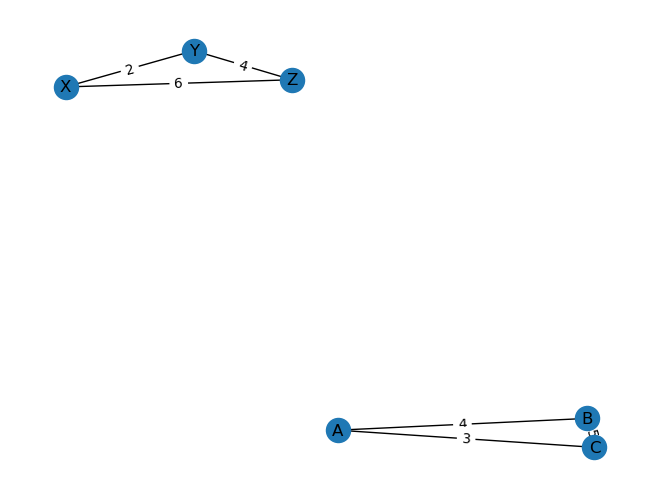

In [20]:
wgraph_4 = WeightedGraph()
wgraph_4.graph = {
    'A': ['B', 'C'],
    'B': ['A', 'C'],
    'C': ['A', 'B'],    
    'X': ['Y', 'Z'],
    'Y': ['X', 'Z'],
    'Z': ['X', 'Y']
}
wgraph_4.weights = {
    ('A', 'B'): 4, ('B', 'A'): 4,
    ('A', 'C'): 3, ('C', 'A'): 3,
    ('B', 'C'): 5, ('C', 'B'): 5,    
    ('X', 'Y'): 2, ('Y', 'X'): 2,
    ('X', 'Z'): 6, ('Z', 'X'): 6,
    ('Y', 'Z'): 4, ('Z', 'Y'): 4
}

print("URUCHOMIENIE ALGORYTMU LISTONOSZA")
try:
    listonosz_4 = wgraph_4.chinski_listonosz('A')
    
    print("\nOstateczna, optymalna trasa dla listonosza:")
    print(" -> ".join(listonosz_4[0]))
    
    print(f"\nKoszt trasy to: {listonosz_4[1]}")
except:
    print("Nie da się znaleść trasy dla tego grafu")
wgraph_4.plot()

<h3>Graf z odizolowanymi wierzchołkami</h3>

URUCHOMIENIE ALGORYTMU DLA WIERZCHOŁKÓW IZOLOWANYCH (PRZYPADEK 5 - PUSTE PRZEDMIEŚCIA)
Graf jest już eulerowski (brak wierzchołków nieparzystych).
Znajdywanie trasy

Ostateczna, optymalna trasa dla listonosza:
A -> C -> E -> D -> B -> A

Koszt trasy to: 20


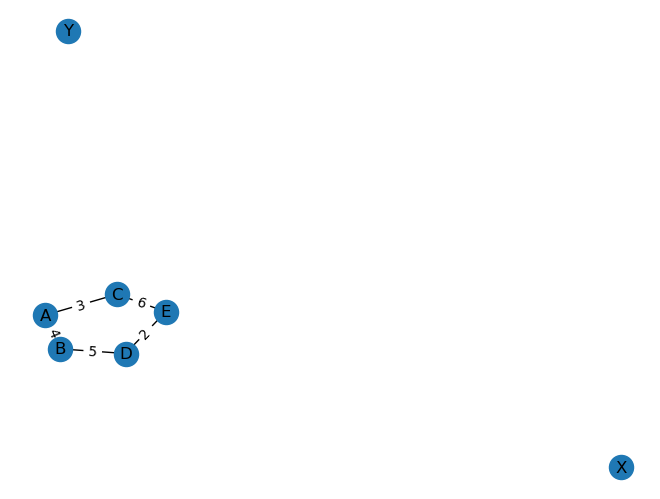

In [22]:
wgraph_5 = WeightedGraph()
wgraph_5.graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D'],
    'C': ['A', 'E'],
    'D': ['B', 'E'],
    'E': ['C', 'D'],    
    'X': [],
    'Y': []
}
wgraph_5.weights = {
    ('A', 'B'): 4, ('B', 'A'): 4,
    ('A', 'C'): 3, ('C', 'A'): 3,
    ('B', 'D'): 5, ('D', 'B'): 5,
    ('C', 'E'): 6, ('E', 'C'): 6,
    ('D', 'E'): 2, ('E', 'D'): 2
}

print("URUCHOMIENIE ALGORYTMU DLA WIERZCHOŁKÓW IZOLOWANYCH (PRZYPADEK 5 - PUSTE PRZEDMIEŚCIA)")
listonosz_5 = wgraph_5.chinski_listonosz('A')

print("\nOstateczna, optymalna trasa dla listonosza:")
print(" -> ".join(listonosz_5[0]))

print(f"\nKoszt trasy to: {listonosz_5[1]}")
wgraph_5.plot()
